# Modelagem com PyTorch — MLP para Predição de Churn

Notebook dedicado à construção, treinamento e avaliação de uma **Rede Neural (MLP)** utilizando PyTorch para o problema de churn.

**Etapas:**
1. Preparação dos Dados (replicando pipeline do `eda.ipynb`)
2. Arquitetura da MLP (PyTorch)
3. Loop de Treinamento com Batching e Early Stopping
4. Comparação MLP vs Modelos Baseline (6 métricas)
5. Análise de Trade-off de Custo: Falsos Positivos vs Falsos Negativos
6. Registro de Experimentos no MLflow

## 1. Setup e Preparação dos Dados

In [46]:
# Bibliotecas
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import (
    SelectKBest, chi2, mutual_info_classif, f_classif,
    RFE, SelectFromModel
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, confusion_matrix,
    classification_report, roc_curve
)

# XGBoost / LightGBM
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# MLflow
import mlflow
import mlflow.pytorch
import mlflow.sklearn

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {DEVICE}")

Dispositivo: cpu


### 1.1 Carregamento e Pré-processamento

Replicamos o mesmo pipeline de dados do `eda.ipynb` para garantir comparabilidade.

In [34]:
# ── Carregar dados ────────────────────────────────────────────────
df_churn = pd.read_csv("../data/Telco_customer_churn.csv")
print(f"Shape original: {df_churn.shape}")

# ── Remover colunas iniciais ──────────────────────────────────────
df_churn = df_churn.drop(columns=['Count', 'CustomerID', 'Churn Reason'])

# ── Feature Engineering ───────────────────────────────────────────
# 1. Perfil de alto risco: Fibra óptica + Contrato mensal
df_churn['high_risk_profile'] = (
    (df_churn['Internet Service'] == 'Fiber optic') &
    (df_churn['Contract'] == 'Month-to-month')
).astype(int)

# 2. Idoso isolado: Senior + Sem parceiro + Sem dependentes
df_churn['isolated_senior'] = (
    (df_churn['Senior Citizen'] == 'Yes') &
    (df_churn['Partner'] == 'No') &
    (df_churn['Dependents'] == 'No')
).astype(int)

# 3. Contagem de serviços de internet contratados
servicos = ['Online Security', 'Online Backup', 'Device Protection',
            'Tech Support', 'Streaming TV', 'Streaming Movies']
df_churn['internet_services_count'] = sum(
    (df_churn[c] == 'Yes').astype(int) for c in servicos
)

# 4. Custo por mês de permanência
df_churn['cost_per_month'] = df_churn['Monthly Charges'] / (df_churn['Tenure Months'] + 1)

# ── Conversão de tipos ────────────────────────────────────────────
for col in df_churn.columns:
    try:
        df_churn[col] = pd.to_numeric(df_churn[col])
    except (ValueError, TypeError):
        pass

# Total Charges: converter para float e preencher nulos
df_churn['Total Charges'] = pd.to_numeric(df_churn['Total Charges'], errors='coerce')
df_churn['Total Charges'] = df_churn['Total Charges'].fillna(df_churn['Total Charges'].median())

# ── Remover colunas de leakage e geográficas ─────────────────────
colunas_vazar = ['Churn Score', 'CLTV', 'Churn Label']
colunas_geograficas = ['City', 'Country', 'Lat Long', 'Latitude', 'Longitude', 'Zip Code']
colunas_drop = colunas_vazar + colunas_geograficas
df_churn = df_churn.drop(columns=[c for c in colunas_drop if c in df_churn.columns])

# ── One-Hot Encoding ──────────────────────────────────────────────
cat_cols = df_churn.select_dtypes(include=['object', 'category']).columns.tolist()
data_encoded = pd.get_dummies(df_churn, columns=cat_cols, drop_first=False)
bool_cols = data_encoded.select_dtypes(include=bool).columns
data_encoded[bool_cols] = data_encoded[bool_cols].astype(int)

# ── Preparação X e y ──────────────────────────────────────────────
df_model = data_encoded.select_dtypes(include=[np.number]).copy()
X = df_model.drop(columns=['Churn Value'])
y = df_model['Churn Value']
X = X.fillna(X.median())

print(f"Features disponíveis: {X.shape[1]}")
print(f"Distribuição do target:\n{y.value_counts(normalize=True).round(4)}")

Shape original: (7043, 33)
Features disponíveis: 51
Distribuição do target:
Churn Value
0    0.7346
1    0.2654
Name: proportion, dtype: float64


### 1.1 Carregamento e Pré-processamento

Replicamos o mesmo pipeline de dados do `eda.ipynb` para garantir comparabilidade.

In [35]:
# ── Carregar dados ────────────────────────────────────────────────
df_churn = pd.read_csv("../data/Telco_customer_churn.csv")
print(f"Shape original: {df_churn.shape}")

# ── Remover colunas iniciais ──────────────────────────────────────
df_churn = df_churn.drop(columns=['Count', 'CustomerID', 'Churn Reason'])

# ── Feature Engineering ───────────────────────────────────────────
# 1. Perfil de alto risco: Fibra óptica + Contrato mensal
df_churn['high_risk_profile'] = (
    (df_churn['Internet Service'] == 'Fiber optic') &
    (df_churn['Contract'] == 'Month-to-month')
).astype(int)

# 2. Idoso isolado: Senior + Sem parceiro + Sem dependentes
df_churn['isolated_senior'] = (
    (df_churn['Senior Citizen'] == 'Yes') &
    (df_churn['Partner'] == 'No') &
    (df_churn['Dependents'] == 'No')
).astype(int)

# 3. Contagem de serviços de internet contratados
servicos = ['Online Security', 'Online Backup', 'Device Protection',
            'Tech Support', 'Streaming TV', 'Streaming Movies']
df_churn['internet_services_count'] = sum(
    (df_churn[c] == 'Yes').astype(int) for c in servicos
)

# 4. Custo por mês de permanência
df_churn['cost_per_month'] = df_churn['Monthly Charges'] / (df_churn['Tenure Months'] + 1)

# ── Conversão de tipos ────────────────────────────────────────────
for col in df_churn.columns:
    try:
        df_churn[col] = pd.to_numeric(df_churn[col])
    except (ValueError, TypeError):
        pass

# Total Charges: converter para float e preencher nulos
df_churn['Total Charges'] = pd.to_numeric(df_churn['Total Charges'], errors='coerce')
df_churn['Total Charges'] = df_churn['Total Charges'].fillna(df_churn['Total Charges'].median())

# ── Remover colunas de leakage e geográficas ─────────────────────
colunas_vazar = ['Churn Score', 'CLTV', 'Churn Label']
colunas_geograficas = ['City', 'Country', 'Lat Long', 'Latitude', 'Longitude', 'Zip Code']
colunas_drop = colunas_vazar + colunas_geograficas
df_churn = df_churn.drop(columns=[c for c in colunas_drop if c in df_churn.columns])

# ── One-Hot Encoding ──────────────────────────────────────────────
cat_cols = df_churn.select_dtypes(include=['object', 'category']).columns.tolist()
data_encoded = pd.get_dummies(df_churn, columns=cat_cols, drop_first=False)
bool_cols = data_encoded.select_dtypes(include=bool).columns
data_encoded[bool_cols] = data_encoded[bool_cols].astype(int)

# ── Preparação X e y ──────────────────────────────────────────────
df_model = data_encoded.select_dtypes(include=[np.number]).copy()
X = df_model.drop(columns=['Churn Value'])
y = df_model['Churn Value']
X = X.fillna(X.median())

print(f"Features disponíveis: {X.shape[1]}")
print(f"Distribuição do target:\n{y.value_counts(normalize=True).round(4)}")

Shape original: (7043, 33)
Features disponíveis: 51
Distribuição do target:
Churn Value
0    0.7346
1    0.2654
Name: proportion, dtype: float64


In [36]:
# ── Train/Test Split ──────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

# ── Seleção de Features (Top 30 — mesmo processo do eda.ipynb) ──
K = 30
scaler_mm = MinMaxScaler()
X_scaled = pd.DataFrame(scaler_mm.fit_transform(X_train), columns=X_train.columns)

# 1. SelectKBest — ANOVA
skb_f = SelectKBest(score_func=f_classif, k=K)
skb_f.fit(X_scaled, y_train)
anova_scores = pd.Series(skb_f.scores_, index=X_train.columns)

# 2. SelectKBest — Chi2
skb_chi2 = SelectKBest(score_func=chi2, k=K)
skb_chi2.fit(X_scaled, y_train)
chi2_scores = pd.Series(skb_chi2.scores_, index=X_train.columns)

# 3. Mutual Information
mi = mutual_info_classif(X_scaled, y_train, random_state=SEED)
mi_scores = pd.Series(mi, index=X_train.columns)

# 4. Correlação Pearson
corr_target = X_train.corrwith(y_train).abs()

# 5. Random Forest Feature Importance
rf_temp = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_temp.fit(X_train, y_train)
rf_scores = pd.Series(rf_temp.feature_importances_, index=X_train.columns)

# 6. RFE com Logistic Regression
lr_temp = LogisticRegression(max_iter=2000, random_state=SEED)
rfe = RFE(estimator=lr_temp, n_features_to_select=K)
rfe.fit(X_scaled, y_train)
rfe_ranking = pd.Series(rfe.ranking_, index=X_train.columns)

# 7. SelectFromModel
selector_rf = SelectFromModel(rf_temp, threshold='mean', prefit=True)
sfm_mask = pd.Series(selector_rf.get_support().astype(int), index=X_train.columns)

# ── Ranking Agregado ──────────────────────────────────────────────
all_methods = pd.DataFrame({
    'anova':    anova_scores,
    'chi2':     chi2_scores,
    'mi':       mi_scores,
    'pearson':  corr_target,
    'rf_imp':   rf_scores,
    'rfe':      (rfe_ranking.max() - rfe_ranking + 1),  # inverter ranking
    'sfm':      sfm_mask,
})

# Normalizar cada método para [0, 1] e somar
all_norm = (all_methods - all_methods.min()) / (all_methods.max() - all_methods.min() + 1e-10)
ranking_final = all_norm.sum(axis=1).sort_values(ascending=False)

features_selecionadas = ranking_final.head(K).index.tolist()
print(f"\nTop {K} features selecionadas:")
print(features_selecionadas)

X_train_sel = X_train[features_selecionadas]
X_test_sel = X_test[features_selecionadas]

print(f"\nShape treino: {X_train_sel.shape} | Shape teste: {X_test_sel.shape}")

X_train: (5634, 51) | X_test: (1409, 51)

Top 30 features selecionadas:
['cost_per_month', 'high_risk_profile', 'Contract_Month-to-month', 'Tenure Months', 'Online Security_No', 'Tech Support_No', 'Payment Method_Electronic check', 'Monthly Charges', 'Total Charges', 'Dependents_No', 'Contract_Two year', 'Internet Service_Fiber optic', 'Dependents_Yes', 'Online Security_No internet service', 'Device Protection_No internet service', 'Streaming Movies_No internet service', 'Online Backup_No internet service', 'Streaming TV_No internet service', 'Tech Support_No internet service', 'Internet Service_No', 'Paperless Billing_No', 'Contract_One year', 'internet_services_count', 'Online Security_Yes', 'Online Backup_No', 'Tech Support_Yes', 'Partner_No', 'isolated_senior', 'Device Protection_No', 'Internet Service_DSL']

Shape treino: (5634, 30) | Shape teste: (1409, 30)


In [37]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

print(f"Média das features (treino): {X_train_scaled.mean(axis=0)[:5].round(6)}")
print(f"Desvio padrão (treino): {X_train_scaled.std(axis=0)[:5].round(6)}")

Média das features (treino): [ 0.  0.  0. -0.  0.]
Desvio padrão (treino): [1. 1. 1. 1. 1.]


---
## 2. Arquitetura da MLP (PyTorch)

```
Etapa 2: Modelagem com PyTorch
- Construir a arquitetura da Rede Neural (MLP), definindo funções de ativação e função de perda (loss).
- Implementar o loop de treinamento incluindo batching e early stopping.
```


Rede Neural do tipo **Multi-Layer Perceptron** com:
- 3 camadas ocultas (64 → 32 → 16 neurônios)
- Ativação **ReLU** nas camadas ocultas
- **Batch Normalization** para estabilizar o treinamento
- **Dropout** (0.3) para regularização
- Ativação **Sigmoid** na saída (classificação binária)
- Função de perda: **BCELoss** (Binary Cross-Entropy)
- Otimizador: **Adam**

In [38]:
class ChurnDataset(Dataset):
    """Dataset PyTorch para dados tabulares de churn."""

    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y.values if hasattr(y, 'values') else y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [39]:
class ChurnMLP(nn.Module):
    """
    Multi-Layer Perceptron para classificação binária de churn.

    Arquitetura:
        Input (n_features)
        → Linear(64) → BatchNorm → ReLU → Dropout(0.3)
        → Linear(32) → BatchNorm → ReLU → Dropout(0.3)
        → Linear(16) → BatchNorm → ReLU → Dropout(0.3)
        → Linear(1)  → Sigmoid
    """

    def __init__(self, n_features, dropout_rate=0.3):
        super().__init__()
        self.network = nn.Sequential(
            # Camada 1: input → 64
            nn.Linear(n_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            # Camada 2: 64 → 32
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            # Camada 3: 32 → 16
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            # Saída: 16 → 1
            nn.Linear(16, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.network(x).squeeze(-1)


# Instanciar modelo
n_features = X_train_scaled.shape[1]
modelo_mlp = ChurnMLP(n_features).to(DEVICE)
print(modelo_mlp)
print(f"\nTotal de parâmetros: {sum(p.numel() for p in modelo_mlp.parameters()):,}")

ChurnMLP(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=16, out_features=1, bias=True)
    (13): Sigmoid()
  )
)

Total de parâmetros: 4,833


---

```
Etapa 2: Modelagem com PyTorch
- Comparar os resultados da MLP contra os modelos baseline utilizando, no mínimo, 4 métricas diferentes.
- Realizar uma análise do trade-off de custo entre falsos positivos e falsos negativos.
- Registrar todos os experimentos da etapa no MLflow.
```


## 3. Loop de Treinamento com Batching e Early Stopping

In [41]:
def treinar_modelo(modelo, X_train, y_train, X_val, y_val,
                   epochs=200, batch_size=64, lr=1e-3,
                   patience=15, device=DEVICE):
    """
    Treina a MLP com batching e early stopping.

    Parâmetros
    ----------
    modelo : nn.Module
    X_train, y_train : dados de treino (numpy arrays)
    X_val, y_val : dados de validação (numpy arrays)
    epochs : int — número máximo de épocas
    batch_size : int — tamanho do batch
    lr : float — learning rate
    patience : int — épocas sem melhoria para early stopping
    device : torch.device

    Retorna
    -------
    dict com histórico de loss e métricas
    """
    # DataLoaders
    train_dataset = ChurnDataset(X_train, y_train)
    val_dataset = ChurnDataset(X_val, y_val)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Loss e Optimizer
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(modelo.parameters(), lr=lr)

    # Histórico
    historico = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }

    # Early stopping
    melhor_val_loss = float('inf')
    epocas_sem_melhoria = 0
    melhor_estado = None

    for epoch in range(epochs):
        # ── Treino ────────────────────────────────────────────────
        modelo.train()
        train_loss_total = 0.0
        train_corretos = 0
        train_total = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            y_pred = modelo(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            train_loss_total += loss.item() * X_batch.size(0)
            train_corretos += ((y_pred >= 0.5).float() == y_batch).sum().item()
            train_total += X_batch.size(0)

        train_loss = train_loss_total / train_total
        train_acc = train_corretos / train_total

        # ── Validação ─────────────────────────────────────────────
        modelo.eval()
        val_loss_total = 0.0
        val_corretos = 0
        val_total = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = modelo(X_batch)
                loss = criterion(y_pred, y_batch)

                val_loss_total += loss.item() * X_batch.size(0)
                val_corretos += ((y_pred >= 0.5).float() == y_batch).sum().item()
                val_total += X_batch.size(0)

        val_loss = val_loss_total / val_total
        val_acc = val_corretos / val_total

        # Registrar histórico
        historico['train_loss'].append(train_loss)
        historico['val_loss'].append(val_loss)
        historico['train_acc'].append(train_acc)
        historico['val_acc'].append(val_acc)

        # Early stopping
        if val_loss < melhor_val_loss:
            melhor_val_loss = val_loss
            epocas_sem_melhoria = 0
            melhor_estado = modelo.state_dict().copy()
        else:
            epocas_sem_melhoria += 1

        if (epoch + 1) % 10 == 0:
            print(f"Época {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                  f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        if epocas_sem_melhoria >= patience:
            print(f"\n⚠ Early stopping na época {epoch+1} "
                  f"(sem melhoria por {patience} épocas)")
            break

    # Restaurar melhor modelo
    if melhor_estado is not None:
        modelo.load_state_dict(melhor_estado)
        print(f"Melhor val_loss: {melhor_val_loss:.4f}")

    return historico

In [42]:
# ── Treinar a MLP ─────────────────────────────────────────────────
EPOCHS = 200
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
PATIENCE = 15

modelo_mlp = ChurnMLP(n_features).to(DEVICE)

historico = treinar_modelo(
    modelo_mlp,
    X_train_scaled, y_train,
    X_test_scaled, y_test,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    patience=PATIENCE,
)

Época  10/200 | Train Loss: 0.4056 | Val Loss: 0.4134 | Train Acc: 0.8088 | Val Acc: 0.8020
Época  20/200 | Train Loss: 0.4028 | Val Loss: 0.4067 | Train Acc: 0.8076 | Val Acc: 0.8020
Época  30/200 | Train Loss: 0.4022 | Val Loss: 0.4029 | Train Acc: 0.8067 | Val Acc: 0.8034
Época  40/200 | Train Loss: 0.4020 | Val Loss: 0.4080 | Train Acc: 0.8106 | Val Acc: 0.8020

⚠ Early stopping na época 45 (sem melhoria por 15 épocas)
Melhor val_loss: 0.4029


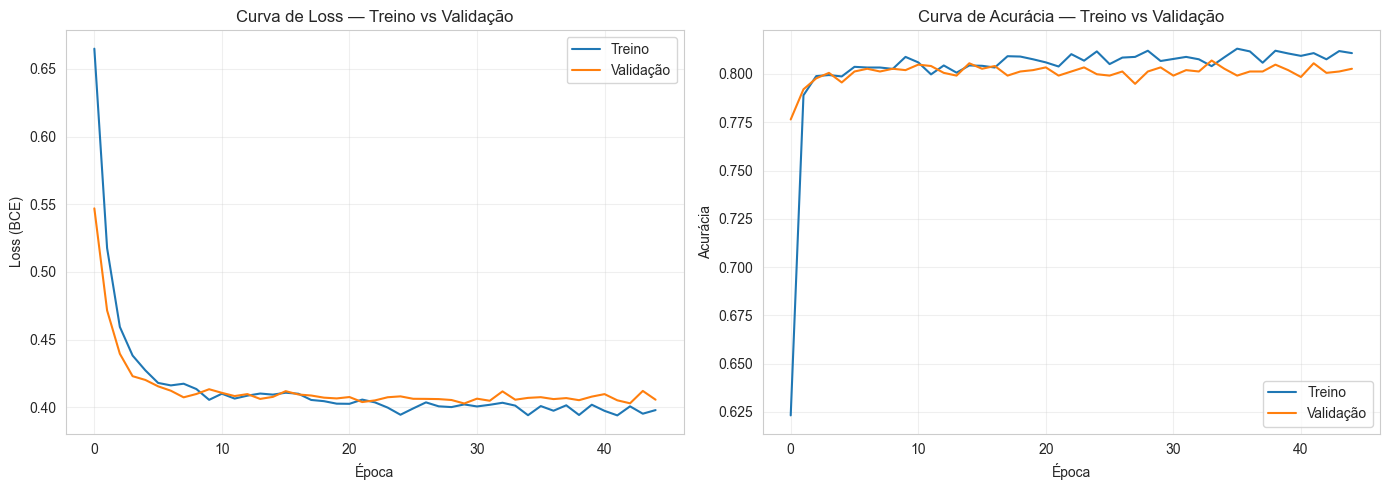

In [43]:
# ── Curvas de Treinamento ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(historico['train_loss'], label='Treino')
axes[0].plot(historico['val_loss'], label='Validação')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss (BCE)')
axes[0].set_title('Curva de Loss — Treino vs Validação')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(historico['train_acc'], label='Treino')
axes[1].plot(historico['val_acc'], label='Validação')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].set_title('Curva de Acurácia — Treino vs Validação')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/curvas_treinamento_mlp.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Comparação MLP vs Modelos Baseline

Comparamos a MLP contra 4 modelos baseline utilizando **6 métricas**:
1. **Accuracy** — proporção de acertos totais
2. **Precision** — proporção de verdadeiros positivos entre os preditos como positivos
3. **Recall** — proporção de verdadeiros positivos entre os realmente positivos
4. **F1-Score** — média harmônica de Precision e Recall
5. **ROC-AUC** — área sob a curva ROC
6. **MCC** (Matthews Correlation Coefficient) — métrica balanceada para classes desbalanceadas

In [44]:
def avaliar_modelo(nome, y_true, y_pred, y_proba):
    """Calcula as 6 métricas de avaliação para um modelo."""
    return {
        'Modelo': nome,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'MCC': matthews_corrcoef(y_true, y_pred),
    }


def predizer_mlp(modelo, X, device=DEVICE):
    """Gera probabilidades e predições da MLP."""
    modelo.eval()
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X).to(device)
        proba = modelo(X_tensor).cpu().numpy()
    pred = (proba >= 0.5).astype(int)
    return pred, proba

In [47]:
# ── Predições da MLP ──────────────────────────────────────────────
mlp_pred, mlp_proba = predizer_mlp(modelo_mlp, X_test_scaled)

# ── Treinar Modelos Baseline ─────────────────────────────────────
# Usamos as features selecionadas (sem scaling para tree-based, com scaling para LR)
baselines = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_split=5,
        random_state=SEED, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        random_state=SEED, n_jobs=-1, eval_metric='logloss'
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, max_depth=8, learning_rate=0.1,
        random_state=SEED, n_jobs=-1, verbose=-1
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=2000, random_state=SEED
    ),
}

resultados = []

# MLP (já treinada)
resultados.append(avaliar_modelo('MLP (PyTorch)', y_test, mlp_pred, mlp_proba))

# Baselines
modelos_treinados = {}
for nome, modelo_base in baselines.items():
    # Logistic Regression usa dados escalados
    if nome == 'Logistic Regression':
        modelo_base.fit(X_train_scaled, y_train)
        y_pred_base = modelo_base.predict(X_test_scaled)
        y_proba_base = modelo_base.predict_proba(X_test_scaled)[:, 1]
    else:
        modelo_base.fit(X_train_sel, y_train)
        y_pred_base = modelo_base.predict(X_test_sel)
        y_proba_base = modelo_base.predict_proba(X_test_sel)[:, 1]

    modelos_treinados[nome] = modelo_base
    resultados.append(avaliar_modelo(nome, y_test, y_pred_base, y_proba_base))
    print(f"{nome}: treinado")

# ── Tabela Comparativa ────────────────────────────────────────────
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

# Formatar para exibição
print("\n" + "═" * 90)
print("COMPARAÇÃO DE MODELOS — 6 MÉTRICAS")
print("═" * 90)
display(df_resultados.style.format({
    'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
    'F1-Score': '{:.4f}', 'ROC-AUC': '{:.4f}', 'MCC': '{:.4f}'
}).highlight_max(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'MCC'],
                color='lightgreen'))

Random Forest: treinado
XGBoost: treinado
LightGBM: treinado
Logistic Regression: treinado

══════════════════════════════════════════════════════════════════════════════════════════
COMPARAÇÃO DE MODELOS — 6 MÉTRICAS
══════════════════════════════════════════════════════════════════════════════════════════


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,MCC
0,MLP (PyTorch),0.8027,0.6455,0.5695,0.6051,0.8530,0.4759
1,Logistic Regression,0.8027,0.6519,0.5508,0.5971,0.8516,0.4706
2,XGBoost,0.7970,0.6350,0.5535,0.5914,0.8430,0.4591
3,Random Forest,0.7935,0.6301,0.5374,0.5801,0.8405,0.4468
4,LightGBM,0.7899,0.6168,0.5508,0.5819,0.8366,0.4435
